## Assignment 1
**Linear Regression by using Deep Neural Network**: Implement Boston housing price prediction problem by linear regression using deep neural network. Use Boston House Price Prediction dataset.

In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [17]:
# load the dataset
df = pd.read_csv('boston_housing_data.csv')

In [18]:
# view
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


### Preprocessing

In [19]:
# check for missing values
df.isnull().any()

CRIM        True
ZN          True
INDUS       True
CHAS        True
NOX        False
RM         False
AGE         True
DIS        False
RAD        False
TAX        False
PTRATIO    False
B          False
LSTAT       True
MEDV       False
dtype: bool

In [20]:
# fill missing values with mean
df = df.fillna(df.mean())
df.isnull().any()

CRIM       False
ZN         False
INDUS      False
CHAS       False
NOX        False
RM         False
AGE        False
DIS        False
RAD        False
TAX        False
PTRATIO    False
B          False
LSTAT      False
MEDV       False
dtype: bool

In [21]:
# separate features and target
x = df.drop('MEDV', axis=1)  # features
y = df['MEDV']  # target

In [22]:
# split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
# standardization - ensures each feature contributes equally & smoothly, leads to higher training speed & accuracy
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

### Build & Train DNN

In [24]:
model =  Sequential()

# input, hidden & output layer
model.add(Dense(64, input_dim = x_train.shape[1], activation='relu'))  # input_dim sets the no. of input features (columns)
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

# compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

/home/amey/Downloads/41335/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(
    x_train, y_train,
    epochs = 300,
    batch_size =  16,
    validation_split = 0.1,
    verbose = 1)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 564.5890 - mae: 21.7580 - val_loss: 514.0867 - val_mae: 21.0428
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 480.2543 - mae: 19.7165 - val_loss: 412.7423 - val_mae: 18.5917
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 364.2114 - mae: 16.6535 - val_loss: 280.1815 - val_mae: 14.9323
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 222.2282 - mae: 12.4184 - val_loss: 143.0924 - val_mae: 9.9778
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 113.6850 - mae: 8.3230 - val_loss: 65.2761 - val_mae: 5.8894
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 60.7062 - mae: 6.0694 - val_loss: 44.0181 - val_mae: 4.5415
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 39.9464 - mae: 4.8272 - val_loss: 37.1624 - val_mae: 4.0038
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 30.1460 - mae: 4.1757 - val_loss: 35.6378 - val_mae: 3.9770
Epoch 9/300
23/23 ━━━━━━━━━━

### Evaluation & Prediction

In [26]:
test_mse, test_mae = model.evaluate(x_test, y_test, verbose = 1)
rmse = np.sqrt(test_mse)
print('MSE on test data: ', rmse)
print('MSE on test data: ', test_mse)
print('MAE on test data: ', test_mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11.9761 - mae: 2.2741
MSE on test data:  3.4606564237584725
MSE on test data:  11.976142883300781
MAE on test data:  2.274139642715454


In [27]:
# make predictions
y_pred = model.predict(x_test)

# compare first few predictions with actual values
print('\nPredicted vs. Actual')
for i in range(5):
    print('Predicted: ', y_pred[i][0], '| Actual: ', y_test.iloc[i])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

Predicted vs. Actual
Predicted:  24.61791 | Actual:  23.6
Predicted:  36.272076 | Actual:  32.4
Predicted:  15.385509 | Actual:  13.6
Predicted:  22.346233 | Actual:  22.8
Predicted:  15.248811 | Actual:  16.1


### Plot

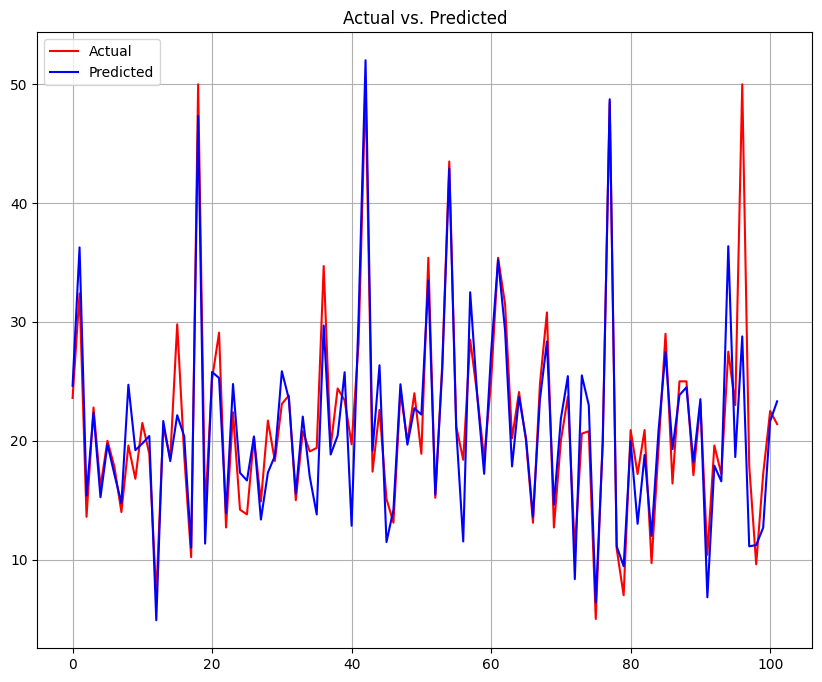

In [28]:
import matplotlib.pyplot as plt

# reshape to 2D array
y_test = np.array(y_test).reshape(-1, 1)

plt.figure(figsize=(10, 8))
plt.plot(y_test, label='Actual', color='red')
plt.plot(y_pred, label='Predicted', color='blue')
plt.title('Actual vs. Predicted')
plt.legend()
plt.grid(True)
plt.show()